In [4]:
import os
import pandas as pd
from google.colab import auth
from google.cloud import storage
from sklearn.model_selection import train_test_split, StratifiedKFold
# Authenticate the current Colab session with Google Cloud
auth.authenticate_user()

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [9]:
# GCS configuration
BUCKET_NAME = "imdb-sentiment-project"
RAW_PREFIX = "raw"
SHARDED_PREFIX = "sharded"

# CV fold to test
GCS_CV_PATH = (
    f"gs://{BUCKET_NAME}/"
    f"{SHARDED_PREFIX}/train.csv"
)

# Read the file
df = pd.read_csv(GCS_CV_PATH)

print(f"Read from: {GCS_CV_PATH}")
print(f"Rows loaded: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Read from: gs://imdb-sentiment-project/sharded/train.csv
Rows loaded: 40,000
Columns: ['review', 'sentiment']


In [15]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [10]:
df.head()

,review,sentiment
0,I've been looking for the name of this film fo...,positive
1,I picked this DVD up at the Dollar Store. The ...,negative
2,This was a movie that I hoped I could suggest ...,negative
3,Exceptionally silly actioner with braindead le...,negative
4,"Follow-up to 1973's ""Walking Tall"" continues t...",negative


In [11]:
df.tail()

,review,sentiment
39995,ZP is deeply related to that youth dream repre...,positive
39996,A very sensitive topic--15 y/o girl abandoned ...,negative
39997,Do NOT avoid this movie. Simply because it is ...,negative
39998,I remember all the hype around this movie when...,negative
39999,"I admired Rob Marshall for Chicago, but Memoir...",negative


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     40000 non-null  object
 1   sentiment  40000 non-null  object
dtypes: object(2)
memory usage: 625.1+ KB


In [13]:
df.isnull().sum()

,0
review,0
sentiment,0


In [14]:
df.duplicated().sum()

np.int64(258)

In [16]:
df.index

RangeIndex(start=0, stop=40000, step=1)

In [17]:
df.describe()

,review,sentiment
count,40000,40000
unique,39742,2
top,Loved today's show!!! It was a variety and not...,positive
freq,4,20000


In [23]:
df = df.drop_duplicates()

In [24]:
df.shape

(39742, 2)

In [28]:
df["sentiment"].value_counts()

,count
sentiment,
positive,19934
negative,19808


In [32]:
## Check sentiment distribution ##

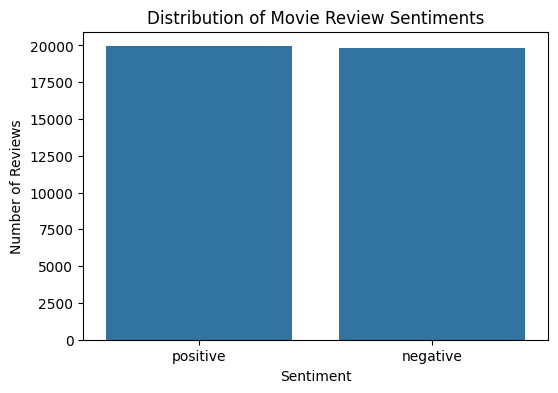

In [31]:
## Visualisaton: ##

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment")
plt.title("Distribution of Movie Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
## Encode the target variable

In [ ]:
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

In [34]:
df.head()

,review,sentiment,label
0,I've been looking for the name of this film fo...,positive,1
1,I picked this DVD up at the Dollar Store. The ...,negative,0
2,This was a movie that I hoped I could suggest ...,negative,0
3,Exceptionally silly actioner with braindead le...,negative,0
4,"Follow-up to 1973's ""Walking Tall"" continues t...",negative,0


In [35]:
## Text preprocessing by:
# Converting to lowercase
# Removing HTML tags
# Removing punctuation
# Removing unnecessary whitespace ##

In [36]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [37]:
sample = """
This movie was AMAZING!!! I really loved it.
"""
print(clean_text(sample))

this movie was amazing i really loved it


In [38]:
## Apply Preprocessing ##

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)

In [40]:
df[["review", "clean_review"]].head()

,review,clean_review
0,I've been looking for the name of this film fo...,i ve been looking for the name of this film fo...
1,I picked this DVD up at the Dollar Store. The ...,i picked this dvd up at the dollar store the d...
2,This was a movie that I hoped I could suggest ...,this was a movie that i hoped i could suggest ...
3,Exceptionally silly actioner with braindead le...,exceptionally silly actioner with braindead le...
4,"Follow-up to 1973's ""Walking Tall"" continues t...",follow up to s walking tall continues the real...


In [41]:
## Split the data into Train, Development and Test ##
## 80% Training
## 10% Development/Validation
## 10% Testing

In [42]:
X = df["clean_review"]
y = df["label"]

In [ ]:
## First Split

In [43]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
## Second Split

In [44]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [45]:
print("Training:", len(X_train))
print("Development:", len(X_dev))
print("Test:", len(X_test))

Training: 31793
Development: 3974
Test: 3975
